# Superstore Dashboard — Python Replica

A faithful replica of the **two-page Power BI dashboard** as individual matplotlib charts (one chart per cell). Each chart carries the corresponding insight from the analysis script (`insight_data_superstore.txt`).

- **Page 1 — Sale Dashboard** (descriptive): KPIs · Sales+Profit by Year · Monthly trend · Segment · Region · Category
- **Page 2 — Profitability & Discount Analysis** (diagnostic): KPIs · Avg profit by discount bucket · Loss-rate by discount bucket · Sub-Category Sales · Sub-Category Profit

Colour language matches Power BI: **blue = Sales · green = Profit / positive · red = loss**.

## Setup

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Power BI-style palette
BLUE      = '#2E8BC0'   # sales bars
GREEN     = '#10B981'   # profit line / positive
RED       = '#EF4444'   # loss / negative
DARK      = '#1F2937'
MUTED     = '#6B7280'
CARD_BG   = '#FFFFFF'
CARD_EDGE = '#E5E7EB'
PAGE_BG   = '#F8F9FA'

plt.rcParams.update({
    'figure.facecolor':  PAGE_BG,
    'axes.facecolor':    CARD_BG,
    'axes.edgecolor':    CARD_EDGE,
    'axes.labelcolor':   DARK,
    'xtick.color':       MUTED,
    'ytick.color':       MUTED,
    'axes.titleweight':  'bold',
    'axes.titlesize':    12,
    'axes.titlecolor':   DARK,
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        110,
})

DATA_PATH = '../data/raw/Sample - Superstore.csv'
df = pd.read_csv(DATA_PATH, encoding='latin-1', parse_dates=['Order Date', 'Ship Date'])
df['Year']  = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.to_period('M').dt.to_timestamp()
print(f'Rows: {len(df):,}   |   Years: {sorted(df["Year"].unique())}')

Rows: 9,994   |   Years: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]


In [32]:
# --- helpers used by every chart ---
def fmt_money(x, _=None):
    a = abs(x)
    if a >= 1e6: return f'${x/1e6:.2f}M'
    if a >= 1e3: return f'${x/1e3:.0f}K'
    return f'${x:.0f}'

def draw_kpi(ax, title, value, value_color=DARK):
    ax.set_facecolor(CARD_BG)
    for s in ax.spines.values():
        s.set_visible(True); s.set_color(CARD_EDGE); s.set_linewidth(1.2)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.72, title, ha='center', va='center',
            fontsize=11, color=MUTED, weight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.30, value, ha='center', va='center',
            fontsize=26, color=value_color, weight='bold', transform=ax.transAxes)

MARGIN_CLR = '#F59E0B'   # margin-% line (amber); used by the Page 1 combo charts

In [33]:
# --- aggregations used by all dashboard cells ---
total_sales  = df['Sales'].sum()
total_profit = df['Profit'].sum()
margin       = total_profit / total_sales * 100
avg_discount = df['Discount'].mean() * 100
loss_pct     = (df['Profit'] < 0).mean() * 100
orders       = df['Order ID'].nunique()

yearly   = df.groupby('Year').agg(Sales=('Sales','sum'), Profit=('Profit','sum'))
monthly  = df.groupby('Month')['Sales'].sum()
segment  = df.groupby('Segment').agg(Sales=('Sales','sum'), Profit=('Profit','sum')).loc[['Consumer','Corporate','Home Office']]
region   = df.groupby('Region').agg(Sales=('Sales','sum'), Profit=('Profit','sum')).sort_values('Sales', ascending=False)
category = df.groupby('Category').agg(Sales=('Sales','sum'), Profit=('Profit','sum')).sort_values('Sales', ascending=False)

disc_labels = ['0%','1-10%','11-20%','21-30%','31-40%','41-50%','51-60%','61-70%','71-80%']
disc_bins   = [-0.01, 0, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]
df['DiscBucket'] = pd.cut(df['Discount'], bins=disc_bins, labels=disc_labels)
avg_profit_bucket = df.groupby('DiscBucket', observed=True)['Profit'].mean().reindex(disc_labels).fillna(0)

subcat = df.groupby('Sub-Category').agg(Sales=('Sales','sum'), Profit=('Profit','sum'))
print('Aggregations ready.')

Aggregations ready.


## EDA — Dataset Overview

Before building the dashboard pages, a quick exploratory pass over the data: shape, date range, missing values, duplicates, and per-column summary statistics.

In [34]:
print('SHAPE & PERIOD')
print('='*50)
print(f'  Rows               : {len(df):,}')
print(f'  Columns            : {df.shape[1]}')
print(f'  Date range         : {df["Order Date"].min().date()}  ->  {df["Order Date"].max().date()}')
print(f'  Years covered      : {sorted(df["Year"].unique())}')
print(f'  Unique orders      : {df["Order ID"].nunique():,}')
print(f'  Unique customers   : {df["Customer ID"].nunique():,}')
print(f'  Unique products    : {df["Product ID"].nunique():,}')

print('\nDATA QUALITY')
print('='*50)
missing = df.isnull().sum()
print('  Missing values     :', 'None' if not missing.any() else '\n' + missing[missing > 0].to_string())
print(f'  Duplicate rows     : {df.duplicated().sum()}')

print('\nNUMERICAL SUMMARY')
print('='*50)
display(df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().round(2))

SHAPE & PERIOD
  Rows               : 9,994
  Columns            : 24
  Date range         : 2014-01-03  ->  2017-12-30
  Years covered      : [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]
  Unique orders      : 5,009
  Unique customers   : 793
  Unique products    : 1,862

DATA QUALITY
  Missing values     : None
  Duplicate rows     : 0

NUMERICAL SUMMARY


,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,-6599.98
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,22638.48,14.00,0.80,8399.98


### Column Dictionary

| Column | Description |
|--------|-------------|
| **Order Date / Ship Date** | When the customer ordered / the order was shipped |
| **Ship Mode** | Standard / Second / First / Same Day |
| **Customer ID / Segment** | Customer identity + Consumer / Corporate / Home Office |
| **Region / State / City** | Geography of the order |
| **Category / Sub-Category / Product Name** | Product taxonomy (3 categories, 17 sub-categories) |
| **Sales** | Revenue in USD for this line item |
| **Quantity** | Units sold |
| **Discount** | Discount applied (0.0 = none, 0.5 = 50% off) |
| **Profit** | Gross profit in USD (negative = loss)  |

In [35]:
# Cardinality of categorical columns
for col in ['Segment', 'Region', 'Category', 'Sub-Category', 'Ship Mode']:
    print(f'  {col:<14} {df[col].nunique():>2} unique  ->  {sorted(df[col].unique())}')

  Segment         3 unique  ->  ['Consumer', 'Corporate', 'Home Office']
  Region          4 unique  ->  ['Central', 'East', 'South', 'West']
  Category        3 unique  ->  ['Furniture', 'Office Supplies', 'Technology']
  Sub-Category   17 unique  ->  ['Accessories', 'Appliances', 'Art', 'Binders', 'Bookcases', 'Chairs', 'Copiers', 'Envelopes', 'Fasteners', 'Furnishings', 'Labels', 'Machines', 'Paper', 'Phones', 'Storage', 'Supplies', 'Tables']
  Ship Mode       4 unique  ->  ['First Class', 'Same Day', 'Second Class', 'Standard Class']


## Page 1 — Sale Dashboard

### KPI Cards

**Insight:** A paradox in six numbers — the company is profitable overall (12.47% margin) yet **18.72% of line items lose money**. The gains are subsidising substantial hidden losses; the rest of the dashboard unpacks where they come from.

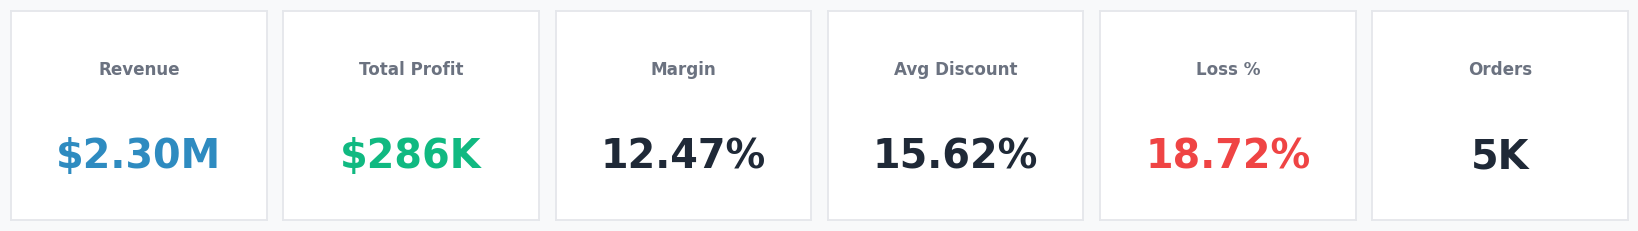

In [36]:
kpis = [
    ('Revenue',      fmt_money(total_sales),   BLUE),
    ('Total Profit', fmt_money(total_profit),  GREEN),
    ('Margin',       f'{margin:.2f}%',         DARK),
    ('Avg Discount', f'{avg_discount:.2f}%',   DARK),
    ('Loss %',       f'{loss_pct:.2f}%',       RED),
    ('Orders',       f'{orders/1000:.0f}K',    DARK),
]
fig, axes = plt.subplots(1, 6, figsize=(15, 2.2))
for ax, (t, v, c) in zip(axes, kpis):
    draw_kpi(ax, t, v, c)
plt.tight_layout()
plt.show()

### Sum of Sales and Sum of Profit by Year

**Insight:** Sales grew +52% (\$0.48M → \$0.73M) and profit +89% (\$49K → \$93K) across 2014–2017 — profit grew faster. But the loss-rate stays ~18.7% every year, so the growth sits *on top of* a stable leak rather than fixing it.

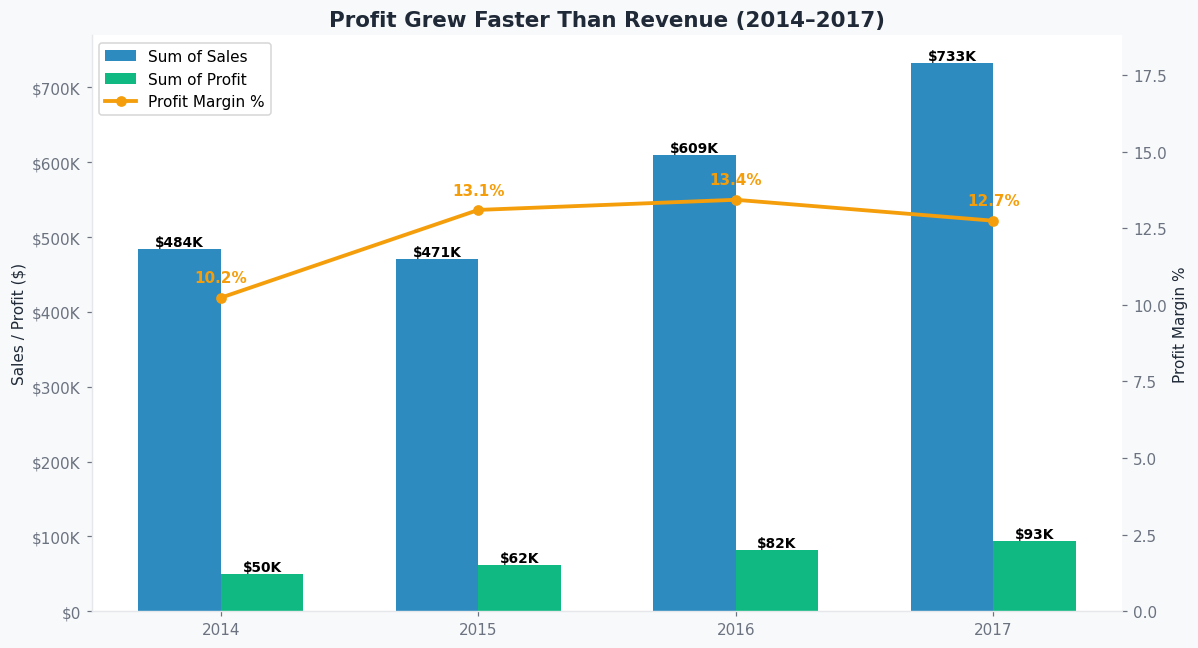

In [37]:
# =========================
# PREP DATA  —  Sales (bar) + Profit (bar) + Margin % (line)
# =========================
years      = yearly.index.astype(str).tolist()
sales      = yearly['Sales'].tolist()
profit     = yearly['Profit'].tolist()
margin_pct = (yearly['Profit'] / yearly['Sales'] * 100).tolist()   # local name: don't clobber global `margin`

x = np.arange(len(years)); width = 0.32

# =========================
# FIGURE + BARS
# =========================
fig, ax1 = plt.subplots(figsize=(11, 6))
bars1 = ax1.bar(x - width/2, sales,  width, label='Sum of Sales',  color=BLUE)
bars2 = ax1.bar(x + width/2, profit, width, label='Sum of Profit', color=GREEN)

for bar in bars1:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height(), fmt_money(bar.get_height()),
             ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height(), fmt_money(bar.get_height()),
             ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_ylabel('Sales / Profit ($)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_money))
ax1.set_xticks(x); ax1.set_xticklabels(years)

# =========================
# SECOND AXIS — MARGIN %
# =========================
ax2 = ax1.twinx()
ax2.plot(x, margin_pct, color=MARGIN_CLR, marker='o', linewidth=2.5, label='Profit Margin %')
ax2.set_ylabel('Profit Margin %')
ax2.set_ylim(0, max(margin_pct) * 1.4)
for i, v in enumerate(margin_pct):
    ax2.text(x[i], v + 0.5, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold', color=MARGIN_CLR)

plt.title('Profit Grew Faster Than Revenue (2014–2017)', fontsize=14, fontweight='bold')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')
ax1.spines['top'].set_visible(False); ax2.spines['top'].set_visible(False)
plt.tight_layout()
plt.show()

### Sum of Sales by Year and Month

**Insight:** Strong, repeating seasonality — a clear Q4 (Nov–Dec) peak and a February trough *every single year*. The recurring Q4 spike is the key signal for inventory and staffing planning.

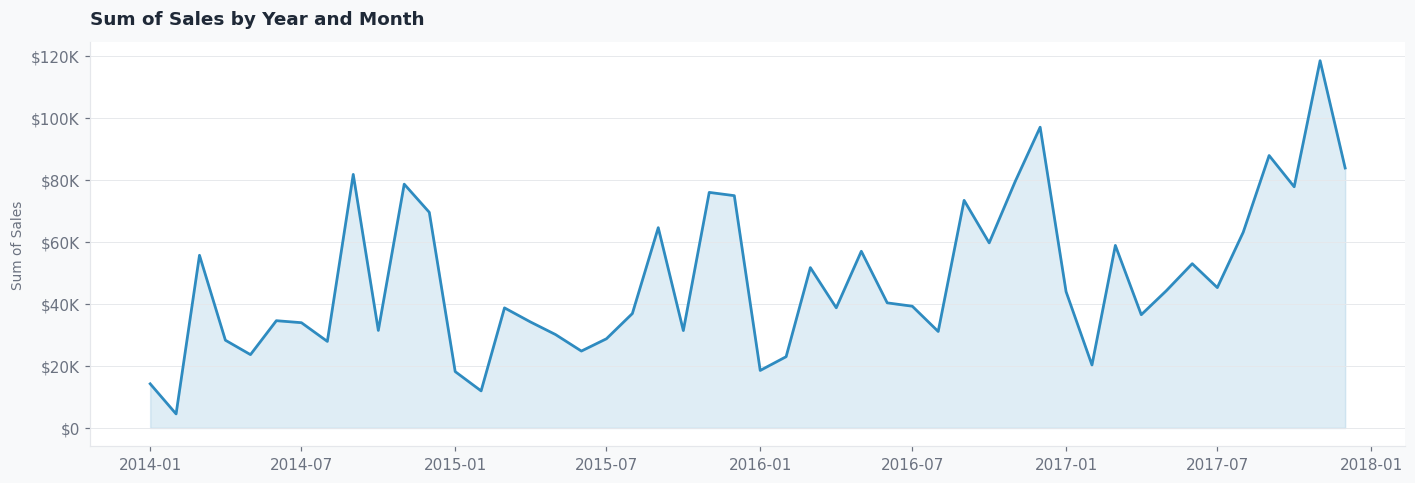

In [38]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.fill_between(monthly.index, monthly.values, alpha=0.15, color=BLUE)
ax.plot(monthly.index, monthly.values, color=BLUE, lw=1.8)
ax.set_title('Sum of Sales by Year and Month', loc='left', pad=12)
ax.set_ylabel('Sum of Sales', fontsize=9, color=MUTED)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_money))
ax.grid(axis='y', color=CARD_EDGE, lw=0.6)
plt.tight_layout()
plt.show()

### Sum of Sales and Sum of Profit by Segment

**Insight:** Consumer is the largest segment by sales (\$1.16M) but has the **worst margin (11.6%)**. Home Office is smallest by revenue yet the most profitable per dollar (14.0%) — raising whether sales effort should tilt toward the higher-margin segments.

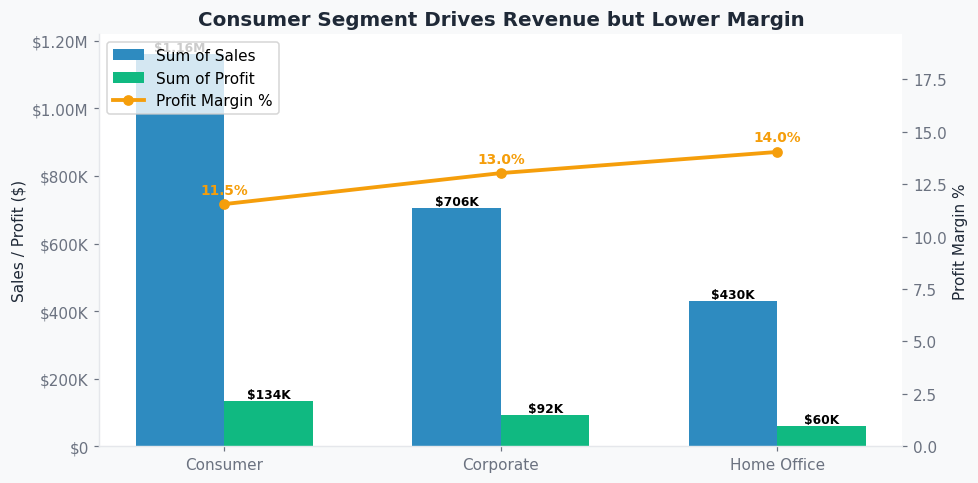

In [39]:
# =========================
# PREP DATA  —  Sales (bar) + Profit (bar) + Margin % (line)
# =========================
segments   = segment.index.tolist()
sales      = segment['Sales'].tolist()
profit     = segment['Profit'].tolist()
margin_pct = (segment['Profit'] / segment['Sales'] * 100).tolist()

x = np.arange(len(segments)); width = 0.32

# =========================
# FIGURE + BARS
# =========================
fig, ax1 = plt.subplots(figsize=(9, 4.5))
bars1 = ax1.bar(x - width/2, sales,  width, label='Sum of Sales',  color=BLUE)
bars2 = ax1.bar(x + width/2, profit, width, label='Sum of Profit', color=GREEN)

for bar in bars1:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height(), fmt_money(bar.get_height()),
             ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar in bars2:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height(), fmt_money(bar.get_height()),
             ha='center', va='bottom', fontsize=8, fontweight='bold')

ax1.set_ylabel('Sales / Profit ($)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_money))
ax1.set_xticks(x); ax1.set_xticklabels(segments)

# =========================
# SECOND AXIS — MARGIN %
# =========================
ax2 = ax1.twinx()
ax2.plot(x, margin_pct, color=MARGIN_CLR, marker='o', linewidth=2.5, label='Profit Margin %')
ax2.set_ylabel('Profit Margin %')
ax2.set_ylim(0, max(margin_pct) * 1.4)
for i, v in enumerate(margin_pct):
    ax2.text(x[i], v + 0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold', color=MARGIN_CLR)

plt.title('Consumer Segment Drives Revenue but Lower Margin', fontsize=13, fontweight='bold')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')
ax1.spines['top'].set_visible(False); ax2.spines['top'].set_visible(False)
plt.tight_layout()
plt.show()

### Sum of Sales and Sum of Profit by Region

**Insight:** Central drags the company average down hard — a **7.9% margin, roughly half** of the West (14.9%) on the same products and brand. A signal to check Central's discounting discipline or product mix.

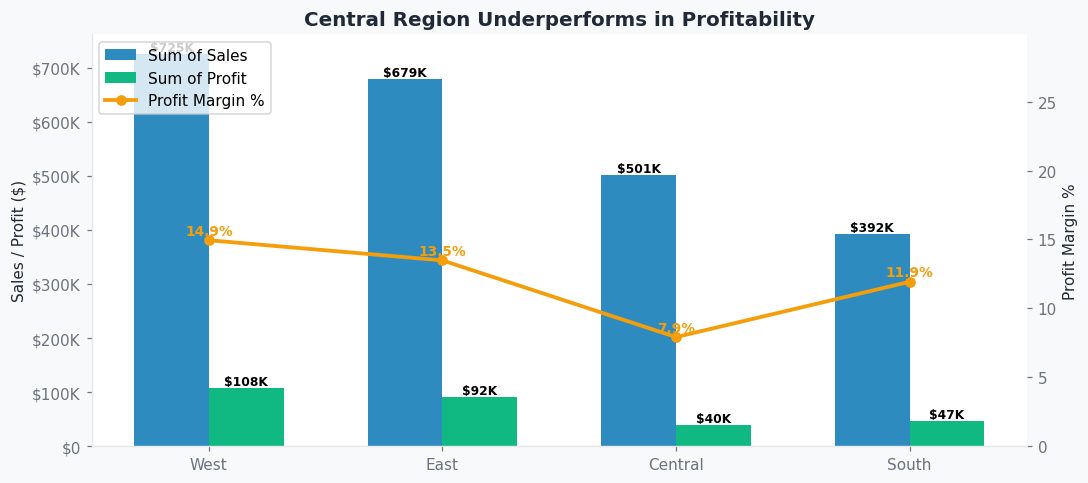

In [40]:
# =========================
# PREP DATA  —  Sales (bar) + Profit (bar) + Margin % (line)
# =========================
regions    = region.index.tolist()
sales      = region['Sales'].tolist()
profit     = region['Profit'].tolist()
margin_pct = (region['Profit'] / region['Sales'] * 100).tolist()

x = np.arange(len(regions)); width = 0.32

# =========================
# FIGURE + BARS
# =========================
fig, ax1 = plt.subplots(figsize=(10, 4.5))
bars1 = ax1.bar(x - width/2, sales,  width, label='Sum of Sales',  color=BLUE)
bars2 = ax1.bar(x + width/2, profit, width, label='Sum of Profit', color=GREEN)

for bar in bars1:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height(), fmt_money(bar.get_height()),
             ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar in bars2:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height(), fmt_money(bar.get_height()),
             ha='center', va='bottom', fontsize=8, fontweight='bold')

ax1.set_ylabel('Sales / Profit ($)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_money))
ax1.set_xticks(x); ax1.set_xticklabels(regions)

# =========================
# SECOND AXIS — MARGIN %
# =========================
ax2 = ax1.twinx()
ax2.plot(x, margin_pct, color=MARGIN_CLR, marker='o', linewidth=2.5, label='Profit Margin %')
ax2.set_ylabel('Profit Margin %')
ax2.set_ylim(0, max(margin_pct) * 2)
for i, v in enumerate(margin_pct):
    ax2.text(x[i], v + 0.4, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold', color=MARGIN_CLR)

plt.title('Central Region Underperforms in Profitability', fontsize=13, fontweight='bold')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')
ax1.spines['top'].set_visible(False); ax2.spines['top'].set_visible(False)
plt.tight_layout()
plt.show()

### Sum of Sales and Sum of Profit by Category

**Insight:** Furniture is a near-zero-margin category — **2.5%** versus Technology 17.4% and Office Supplies 17.0%. It earns roughly the same revenue as Office Supplies but ~one-seventh the profit. The first big red flag.

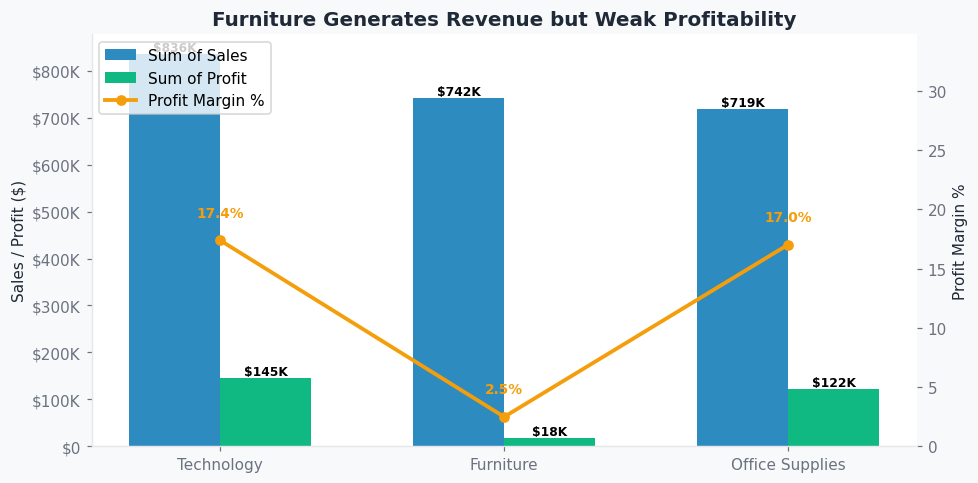

In [49]:
# =========================
# PREP DATA  —  Sales (bar) + Profit (bar) + Margin % (line)
# =========================
categories = category.index.tolist()
sales      = category['Sales'].tolist()
profit     = category['Profit'].tolist()
margin_pct = (category['Profit'] / category['Sales'] * 100).tolist()

x = np.arange(len(categories)); width = 0.32

# =========================
# FIGURE + BARS
# =========================
fig, ax1 = plt.subplots(figsize=(9, 4.5))
bars1 = ax1.bar(x - width/2, sales,  width, label='Sum of Sales',  color=BLUE)
bars2 = ax1.bar(x + width/2, profit, width, label='Sum of Profit', color=GREEN)

for bar in bars1:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height(), fmt_money(bar.get_height()),
             ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar in bars2:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height(), fmt_money(bar.get_height()),
             ha='center', va='bottom', fontsize=8, fontweight='bold')

ax1.set_ylabel('Sales / Profit ($)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_money))
ax1.set_xticks(x); ax1.set_xticklabels(categories)

# =========================
# SECOND AXIS — MARGIN %
# =========================
ax2 = ax1.twinx()
ax2.plot(x, margin_pct, color=MARGIN_CLR, marker='o', linewidth=2.5, label='Profit Margin %')
ax2.set_ylabel('Profit Margin %')
ax2.set_ylim(0, max(margin_pct) * 2)
for i, v in enumerate(margin_pct):
    ax2.text(x[i], v + 2, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold', color=MARGIN_CLR)

plt.title('Furniture Generates Revenue but Weak Profitability', fontsize=13, fontweight='bold')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')
ax1.spines['top'].set_visible(False); ax2.spines['top'].set_visible(False)
plt.tight_layout()
plt.show()

## Page 2 — Profitability & Discount Analysis

### Average of Profit by Discount Bucket

**Insight:** The 20% discount level is a **cliff, not a slope**. Below 20%, average profit per order is positive; at 21%+ every bucket loses money on average (steepest at 41–50%, –\$299).

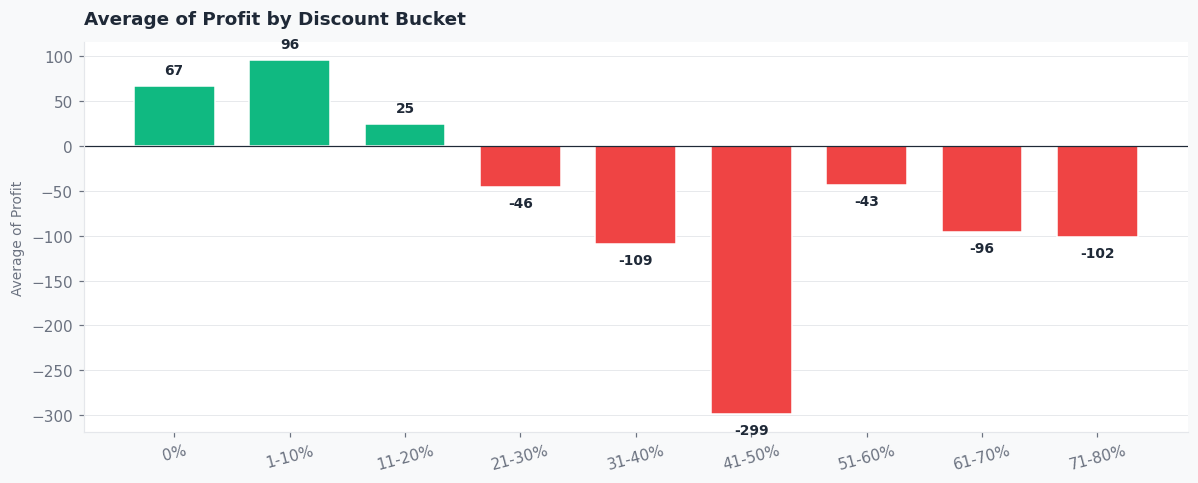

In [42]:
fig, ax = plt.subplots(figsize=(11, 4.5))
colors = [GREEN if v >= 0 else RED for v in avg_profit_bucket.values]
bars = ax.bar(avg_profit_bucket.index, avg_profit_bucket.values,
              color=colors, edgecolor='white', width=0.7, zorder=2)
for b, v in zip(bars, avg_profit_bucket.values):
    ax.text(b.get_x()+b.get_width()/2,
            v + (10 if v >= 0 else -10),
            f'{v:.0f}', ha='center',
            va='bottom' if v >= 0 else 'top',
            fontsize=9, color=DARK, weight='bold')
ax.axhline(0, color=DARK, lw=0.8)
ax.set_title('Average of Profit by Discount Bucket', loc='left', pad=12)
ax.set_ylabel('Average of Profit', fontsize=9, color=MUTED)
ax.grid(axis='y', color=CARD_EDGE, lw=0.6, zorder=1)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

### Loss-Rate by Discount Bucket

**Insight (the key chart in the deck):** the cliff is not gradual — loss rate jumps from 14% (11–20%) to **91.6%** (21–30%) almost overnight, and hits 100% above 40%. Where the Average-Profit chart smooths the risk, this shows the truth: crossing 20% is *near-certain* to lose money. → leads directly to **Recommendation #1: cap discounts at 20%**.

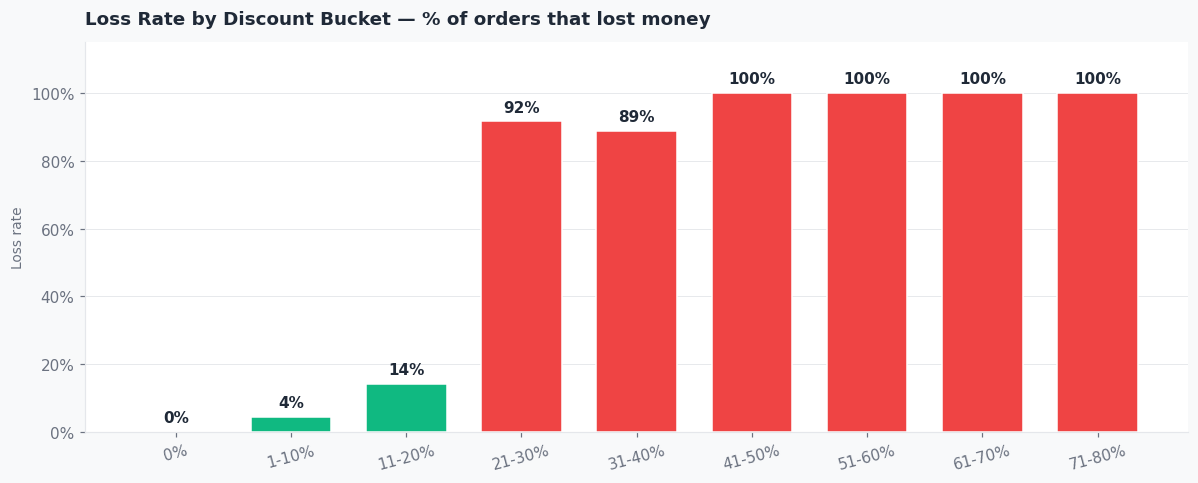

In [43]:
loss_rate_bucket = (df.groupby('DiscBucket', observed=True)
                      .apply(lambda g: (g['Profit'] < 0).mean() * 100)
                      .reindex(disc_labels)
                      .fillna(0))

def loss_color(r):
    if r < 20:   return GREEN
    if r < 50:   return '#F59E0B'
    return RED
colors = [loss_color(r) for r in loss_rate_bucket.values]

fig, ax = plt.subplots(figsize=(11, 4.5))
bars = ax.bar(loss_rate_bucket.index, loss_rate_bucket.values,
              color=colors, edgecolor='white', width=0.7, zorder=2)
for b, v in zip(bars, loss_rate_bucket.values):
    ax.text(b.get_x()+b.get_width()/2, v + 2, f'{v:.0f}%',
            ha='center', va='bottom', fontsize=10, color=DARK, weight='bold')
ax.set_title('Loss Rate by Discount Bucket — % of orders that lost money',
             loc='left', pad=12)
ax.set_ylabel('Loss rate', fontsize=9, color=MUTED)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.set_ylim(0, 115)
ax.grid(axis='y', color=CARD_EDGE, lw=0.6, zorder=1)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

### Sum of Sales by Sub-Category

**Insight:** Phones, Chairs, Storage and **Tables** lead by revenue. Tables being a top-4 seller sets up the punchline in the next chart — what all that sales volume actually costs.

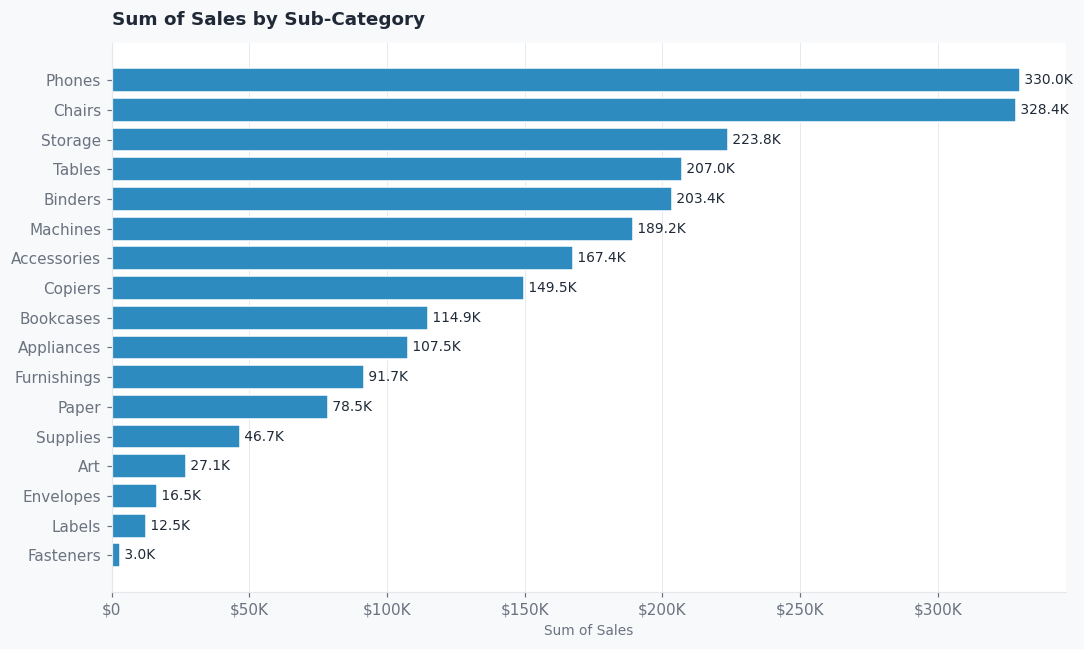

In [50]:
subcat_sales = subcat.sort_values('Sales', ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(subcat_sales.index, subcat_sales['Sales'],
               color=BLUE, edgecolor='white', zorder=2)
for b, v in zip(bars, subcat_sales['Sales']):
    ax.text(v, b.get_y()+b.get_height()/2, f' {v/1e3:.1f}K',
            va='center', fontsize=9, color=DARK)
ax.set_title('Sum of Sales by Sub-Category', loc='left', pad=12)
ax.set_xlabel('Sum of Sales', fontsize=9, color=MUTED)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_money))
ax.grid(axis='x', color=CARD_EDGE, lw=0.6, zorder=1)
plt.tight_layout()
plt.show()

### Total Profit by Sub-Category

**Insight:** The punchline — **Tables is a top-4 seller yet the worst profit-maker (–\$17.7K)**; every unit sold moves the bottom line backwards. Meanwhile **Copiers**, barely visible on the sales chart, is the single most profitable sub-category (+\$55K) thanks to protected premium pricing.

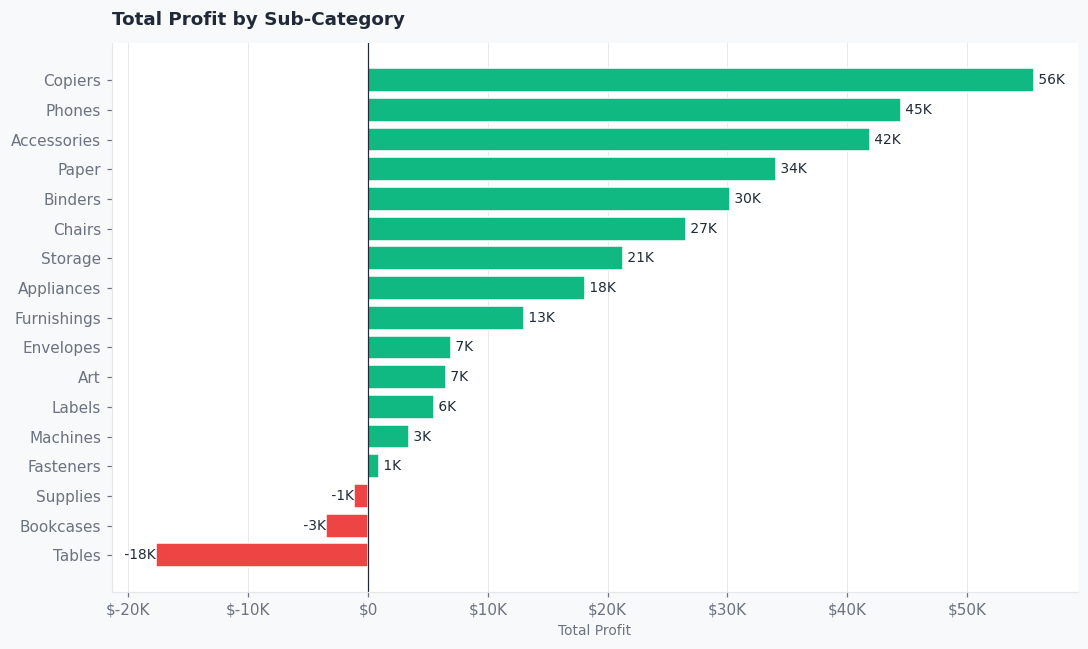

In [51]:
subcat_profit = subcat.sort_values('Profit', ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
p_colors = [GREEN if v >= 0 else RED for v in subcat_profit['Profit']]
bars = ax.barh(subcat_profit.index, subcat_profit['Profit'],
               color=p_colors, edgecolor='white', zorder=2)
for b, v in zip(bars, subcat_profit['Profit']):
    ax.text(v, b.get_y()+b.get_height()/2,
            f' {v/1e3:.0f}K',
            va='center', ha='left' if v >= 0 else 'right',
            fontsize=9, color=DARK)
ax.axvline(0, color=DARK, lw=0.8)
ax.set_title('Total Profit by Sub-Category', loc='left', pad=12)
ax.set_xlabel('Total Profit', fontsize=9, color=MUTED)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_money))
ax.grid(axis='x', color=CARD_EDGE, lw=0.6, zorder=1)
plt.tight_layout()
plt.show()

## Key Insights & Recommendations

A read-out of the two-page dashboard. Each recommendation is limited to one the charts above directly support.

**The story in one line:** Superstore is profitable overall (12.47% margin) but loses money on 18.72% of line items — and the single biggest lever is discount discipline.

| # | Recommendation | Evidence (chart on this dashboard) |
|---|----------------|------------------------------------|
| 1 | **Cap discounts at 20%** — above requires approval | *Loss-Rate by Discount Bucket*: 14% → 91.6% crossing 20%, 100% above 40% |
| 2 | **Re-cost or discontinue Tables** | *Total Profit by Sub-Category*: –\$17.7K — the worst sub-category despite being a top-4 seller |
| 3 | **Protect Copiers' pricing** — no volume discounts | *Total Profit by Sub-Category*: +\$55K — the single most profitable line |
| 4 | **Pre-stock Q4 inventory** to seasonality | *Sum of Sales by Year & Month*: a Q4 peak repeats every year 2014–2017 |